In [46]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mutual_info_score
from ibl_info.utils import (
    check_config,
    equipopulated_binning,
    equispaced_binning,
)
import ibl_info.measures.information_measures as info
import seaborn as sns
from glob import glob
import pickle as pkl
from one.api import ONE

In [22]:
with open(
    "../data/generated/pairwise_decoders/choice/goodsessions/equipopulated_5/selective_decomposition_CP_choice_decoder_goodsessions_projections_equipopulated_5.pkl",
    "rb",
) as f:
    cp_data = pkl.load(f)

In [23]:
decoding_results = cp_data["37e96d0b-5b4b-4c6e-9b29-7edbdc94bbd0"]["decoding_results"]

In [76]:
def analyze_bootstraps_custom(
    cong_preds_list,
    cong_y_list,
    incong_preds_list,
    incong_y_list,
    n_bins=3,
):
    """
    Analyzes bootstraps using USER-PROVIDED binning and MI functions.

    Parameters:
    -----------
    cong/incong_preds_list : List of arrays (one per bootstrap)
    cong/incong_y_list     : List of arrays (one per bootstrap)
    """

    n_bootstraps = len(cong_preds_list)
    strategies = ["Equispaced", "Pooled Quantile"]

    # Storage: results[strategy][condition] = { 'c0': [], 'c1': [], 'mi': [] }
    results = {
        s: {
            "Congruent": {"c0": [], "c1": [], "mi": []},
            "Incongruent": {"c0": [], "c1": [], "mi": []},
        }
        for s in strategies
    }

    # --- LOOP THROUGH BOOTSTRAPS ---
    for i in range(n_bootstraps):
        # 1. Get Data for this bootstrap
        cp, cy = np.array(cong_preds_list[i]), np.array(cong_y_list[i])
        ip, iy = np.array(incong_preds_list[i]), np.array(incong_y_list[i])

        # --- STRATEGY 1: EQUISPACED ---
        # Fixed edges (0-1), so we can bin separately
        c_eq = equispaced_binning(cp, n_bins=n_bins)
        i_eq = equispaced_binning(ip, n_bins=n_bins)

        # --- STRATEGY 2: POOLED EQUIPOPULATED (Your specific logic) ---
        # "Treat the output all together and then subset using indices"
        combined_preds = np.concatenate([cp, ip])

        # Bin the global set
        combined_binned = equipopulated_binning(combined_preds, n_bins=n_bins)
        # Split back using indices
        split_idx = len(cp)
        c_pool = combined_binned[:split_idx]
        i_pool = combined_binned[split_idx:]

        # --- STRATEGY 3: SEPARATE EQUIPOPULATED (The "Danger" control) ---
        # Bin independently
        c_sep = equipopulated_binning(cp, n_bins=n_bins)
        i_sep = equipopulated_binning(ip, n_bins=n_bins)

        # --- HELPER: COMPUTE METRICS ---
        def store_metrics(binned_data, y_true, strategy, condition):
            # 1. Compute User's Custom MI
            mi_val = info.corrected_mutual_information(
                source=np.asarray(binned_data, dtype=np.int32),
                target=np.asarray(y_true, dtype=np.int32),
            )

            # 2. Count Bin Distributions (for visualization)
            # We assume bins are integers 0..n_bins-1
            counts_0 = np.zeros(n_bins)
            counts_1 = np.zeros(n_bins)

            for b in range(n_bins):
                counts_0[b] = np.sum((binned_data == b) & (y_true == 0))
                counts_1[b] = np.sum((binned_data == b) & (y_true == 1))

            # Normalize to proportion (optional, keeps bars comparable)
            total = len(y_true)
            if total > 0:
                counts_0 /= total
                counts_1 /= total

            results[strategy][condition]["c0"].append(counts_0)
            results[strategy][condition]["c1"].append(counts_1)
            results[strategy][condition]["mi"].append(mi_val)

        # Store everything
        store_metrics(c_eq, cy, "Equispaced", "Congruent")
        store_metrics(i_eq, iy, "Equispaced", "Incongruent")

        store_metrics(c_pool, cy, "Pooled Quantile", "Congruent")
        store_metrics(i_pool, iy, "Pooled Quantile", "Incongruent")

    # --- PLOTTING ---
    plot_results(results, n_bootstraps, strategies, n_bins)


def plot_results(results, n_bootstraps, strategies, n_bins):
    """
    Separate plotting function to keep the logic clean
    """
    # 1. PLOT BIN DISTRIBUTIONS
    fig1, axes = plt.subplots(2, 2, figsize=(10, 10), sharey=True)
    bar_width = 0.35
    index = np.arange(n_bins)

    for row_idx, cond in enumerate(["Congruent", "Incongruent"]):
        for col_idx, strat in enumerate(strategies):
            ax = axes[row_idx, col_idx]

            # Aggregate stats across bootstraps
            c0_mat = np.array(results[strat][cond]["c0"])  # Shape: (n_boots, n_bins)
            c1_mat = np.array(results[strat][cond]["c1"])

            mean_c0 = np.mean(c0_mat, axis=0)
            std_c0 = np.std(c0_mat, axis=0)
            mean_c1 = np.mean(c1_mat, axis=0)
            std_c1 = np.std(c1_mat, axis=0)

            # Plot
            ax.bar(
                index,
                mean_c0,
                bar_width,
                yerr=std_c0,
                capsize=5,
                label="Class 0",
                color="blue",
                alpha=0.6,
            )
            ax.bar(
                index + bar_width,
                mean_c1,
                bar_width,
                yerr=std_c1,
                capsize=5,
                label="Class 1",
                color="orange",
                alpha=0.6,
            )

            ax.set_title(f"{cond}\n{strat}", fontsize=11, fontweight="bold")
            ax.set_xticks(index + bar_width / 2)
            ax.set_xticklabels([f"Bin {i}" for i in range(n_bins)])

            # Highlight warning
            if strat == "Separate Quantile" and cond == "Incongruent":
                ax.set_facecolor("#fff0f0")
    sns.despine()
    axes[0, 0].legend()
    axes[0, 0].set_ylabel("Proportion of Trials")
    axes[1, 0].set_ylabel("Proportion of Trials")
    fig1.suptitle("Average Bin Distribution across Bootstraps", fontsize=16)
    plt.tight_layout()

    # 2. PLOT MI BOXPLOTS
    fig2, ax2 = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

    for i, cond in enumerate(["Congruent", "Incongruent"]):
        data_to_plot = [results[s][cond]["mi"] for s in strategies]
        ax2[i].boxplot(data_to_plot, labels=strategies)
        ax2[i].set_title(f"Mutual Information: {cond}")

    fig2.suptitle("Impact on Mutual Information Metric", fontsize=14)
    sns.despine()
    plt.tight_layout()
    plt.show()

In [77]:
my_cong_preds_bootstraps = []
my_cong_y_bootstraps = []
my_incong_preds_bootstraps = []
my_incong_y_bootstraps = []

for idx in range(len(decoding_results)):
    my_cong_preds_bootstraps.append(decoding_results[idx]["probs_B_cong"][:, 0])
    my_cong_y_bootstraps.append(decoding_results[idx]["y_cong"])
    my_incong_preds_bootstraps.append(decoding_results[idx]["probs_B_incong"][:, 0])
    my_incong_y_bootstraps.append(decoding_results[idx]["y_incong"])

/var/folders/nr/dw4dxrwd2r3ctns0lnz88jjc0000gn/T/ipykernel_4561/3746351516.py:157: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax2[i].boxplot(data_to_plot, labels=strategies)
/var/folders/nr/dw4dxrwd2r3ctns0lnz88jjc0000gn/T/ipykernel_4561/3746351516.py:157: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax2[i].boxplot(data_to_plot, labels=strategies)


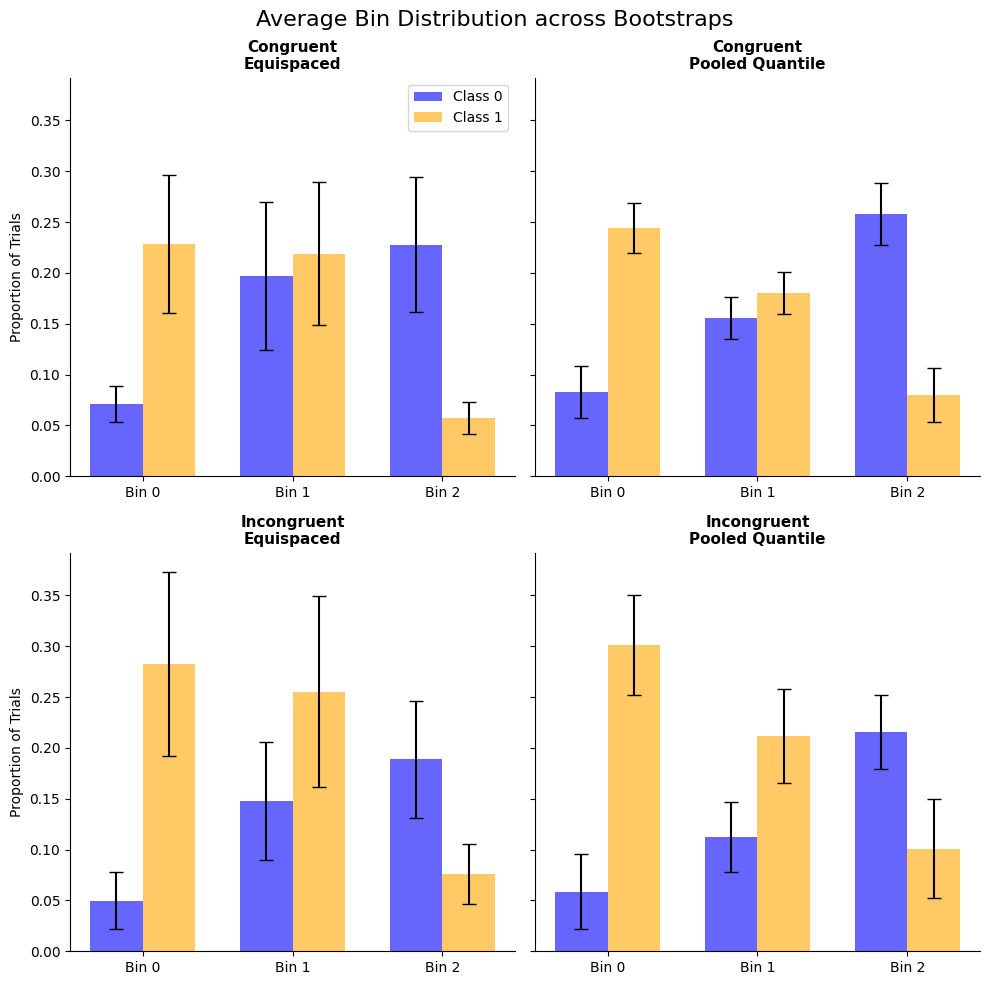

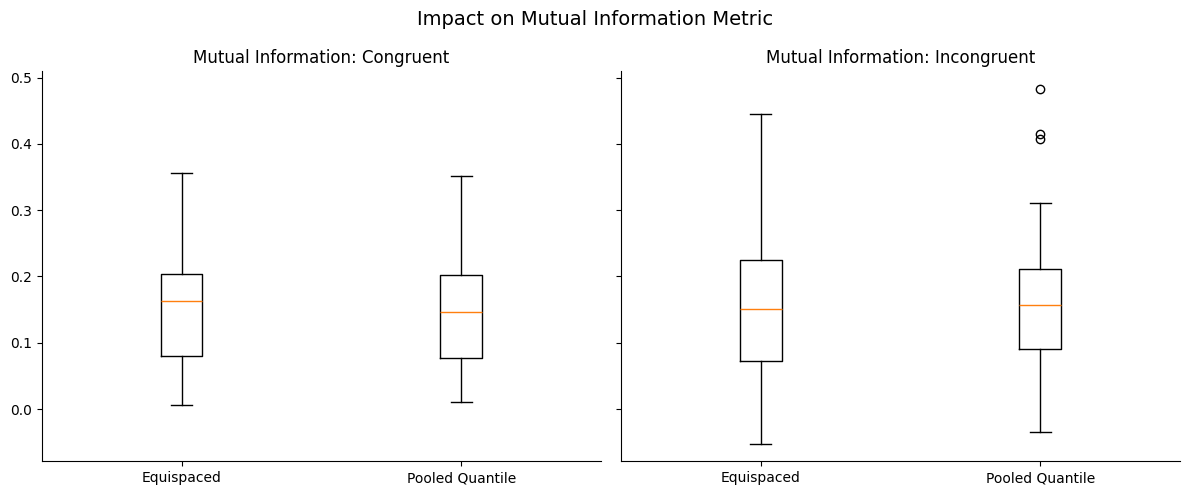

In [78]:
analyze_bootstraps_custom(
    cong_preds_list=my_cong_preds_bootstraps,
    cong_y_list=my_cong_y_bootstraps,
    incong_preds_list=my_incong_preds_bootstraps,
    incong_y_list=my_incong_y_bootstraps,
    n_bins=3,
)